<h1>Objective 2</h1>
Your team will perform two related, but distinct linear regression tasks as specified below.


<h2>Linear Regression 2.1</h2>
<ol>
    <li>Build and evaluate a linear regression model that:</li>
        <ol>
            <li>predicts the goal difference between two opposing teams in FIFA World Cup 2026 matches.</li>
        </ol>
    </li>
    <li>You must compile a dataset that comprises</li>
        <ol>
            <li>104 rows</li>
            <li>each representing an actual match in the FIFA World Cup 2026. </li>
        </ol>
    </li>
    <li>Your dataset must include</li>
        <ol>
        <li>exactly eight (8) explanatory variables = 2 per group member</li>
        <li>excluding any ID field</li>
        </ol>
    </li>
    <li>You must thoughtfully decide what these explanatory variables would be and then collect their corresponding data.</li>
    </li>
</ol>

Note: All explanatory variables must provide information t
variable for predicting the goal difference of that match.

<strong>Analysis completed by Danielle Whitney</strong><br>

<em>Group 23 - HIT140 - Charles Darwin University</em><br>

<em>September 2026</em><br>


In [2]:
# import libraries for analysis question 2.1 Linear Regression
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt
import math
import numpy as np

# load the data files for analysis question 2.1 Linear Regression
attempts = pd.read_csv("attempts_at_goal_team.csv")
fifa_stats = pd.read_csv("FIFA_Site_Team_Stats.csv")
rounds2026 = pd.read_csv("rounds2026.csv")

In [3]:
# inspect the attempts table for data types and null values
attempts.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 17 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   rank                              48 non-null     int64  
 1   team_id                           48 non-null     int64  
 2   team                              48 non-null     str    
 3   team_abbrv                        48 non-null     str    
 4   goals                             48 non-null     int64  
 5   assists                           48 non-null     int64  
 6   attempt_at_goal                   48 non-null     int64  
 7   attempt_ontarget                  48 non-null     int64  
 8   offtarget_attempt                 48 non-null     int64  
 9   attempt_goal_convRate_percentage  48 non-null     int64  
 10  attempt_inside_pa                 48 non-null     int64  
 11  attempt_outside_pa                48 non-null     int64  
 12  headed_attempt_goal  

In [4]:
# review the attempts table
attempts.head()

,rank,team_id,team,team_abbrv,goals,assists,attempt_at_goal,attempt_ontarget,offtarget_attempt,attempt_goal_convRate_percentage,attempt_inside_pa,attempt_outside_pa,headed_attempt_goal,xG,xG_efficiency,corners,possession_control_percentage
0,1,97,Spain,ESP,14,10,140,54,59,10,79,61,22,17.48,0.8x,54,58
1,2,19,France,FRA,20,18,139,59,59,14,77,62,10,16.78,1.19x,51,51
2,3,18,England,ENG,20,14,118,52,40,17,88,30,27,15.03,1.33x,40,50
3,4,2,Argentina,ARG,19,12,115,46,49,17,66,49,22,15.45,1.23x,41,53
4,5,5,Belgium,BEL,14,10,112,35,43,13,74,38,16,10.62,1.32x,24,46


In [5]:
# inspect the attempts table for summary statistics
attempts.describe()

,rank,team_id,goals,assists,attempt_at_goal,attempt_ontarget,offtarget_attempt,attempt_goal_convRate_percentage,attempt_inside_pa,attempt_outside_pa,headed_attempt_goal,xG,corners,possession_control_percentage
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,24.187500,46.666667,6.416667,4.645833,53.562500,18.479167,22.562500,11.229167,32.583333,20.979167,8.729167,5.533333,19.812500,44.333333
std,13.822055,37.125052,5.164664,4.128209,31.169343,13.473362,12.517063,5.482039,20.544537,12.543524,5.452852,4.204746,12.156176,8.213464
min,1.000000,1.000000,0.000000,0.000000,17.000000,2.000000,5.000000,0.000000,6.000000,6.000000,2.000000,1.120000,5.000000,27.000000
25%,12.500000,12.750000,2.000000,1.750000,31.750000,8.000000,14.750000,6.000000,16.750000,12.000000,5.000000,2.340000,10.000000,37.000000
50%,24.500000,48.500000,5.000000,3.000000,44.500000,14.000000,18.000000,11.500000,26.000000,18.000000,7.000000,4.260000,16.500000,46.000000
75%,34.750000,67.250000,10.000000,7.250000,69.250000,23.750000,28.250000,14.000000,44.750000,26.000000,12.000000,7.245000,26.000000,51.000000
max,47.000000,112.000000,20.000000,18.000000,140.000000,59.000000,59.000000,25.000000,88.000000,62.000000,27.000000,17.480000,54.000000,58.000000


In [6]:
attempts_renamed = attempts.rename(columns={
    "team": "Team",
    "team_abbrv": "TeamAbbr",
    "goals": "Goals",
    "assists": "Assists",
    "attempt_at_goal": "Attempts_at_goal",
    "attempt_ontarget": "Attempts_on_target",
    "offtarget_attempt": "Off_Target_Attempts",
    "attempt_goal_convRate_percentage": "Attempts_at_goal_conversionrate(%)",
    "attempt_inside_pa": "Attempts_Inside_PenaltyArea",
    "attempt_outside_pa": "Attemps_Outside_PenaltyArea",
    "headed_attempt_goal": "Headed_Attemps_at_Goal",
    "xG": "xG",
    "xG_efficiency": "xG_Efficiency",
    "corners": "Corners",
    "possession_control_percentage": "Possession_Control(%)"
})

In [7]:
fifa_stats.info()

<class 'pandas.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 15 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Rank                                 48 non-null     int64  
 1   Team                                 48 non-null     str    
 2   Goals                                48 non-null     int64  
 3   Assists                              48 non-null     int64  
 4   Attempts_at_goal                     48 non-null     int64  
 5   Attempts_on_target                   48 non-null     int64  
 6   Off_Target_Attempts                  48 non-null     int64  
 7   Attempts_ at_goal_conversionrate(%)  48 non-null     int64  
 8   Attempts_Inside_PenaltyArea          48 non-null     int64  
 9   Attemps_Outside_PenaltyArea          48 non-null     int64  
 10  Headed_Attemps_at_Goal               48 non-null     int64  
 11  xG                                   48 non-n

In [8]:
fifa_stats.head()

,Rank,Team,Goals,Assists,Attempts_at_goal,Attempts_on_target,Off_Target_Attempts,Attempts_ at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
0,1,England,20,14,118,52,40,17,88,30,27,15.03,1.33,40,50
1,1,France,20,18,139,59,59,14,77,62,10,16.78,1.19,51,51
2,3,Argentina,19,12,115,46,49,17,66,49,22,15.45,1.23,41,53
3,4,Spain,14,10,140,54,59,10,79,61,22,17.48,0.80,54,58
4,4,Belgium,14,10,112,35,43,13,74,38,16,10.62,1.32,24,46


In [9]:
fifa_stats.describe()

,Rank,Goals,Assists,Attempts_at_goal,Attempts_on_target,Off_Target_Attempts,Attempts_ at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
count,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000,48.000000
mean,22.687500,6.416667,4.645833,53.562500,18.479167,22.562500,11.229167,32.583333,20.979167,8.729167,5.533333,1.167708,19.812500,44.333333
std,13.184705,5.164664,4.128209,31.169343,13.473362,12.517063,5.482039,20.544537,12.543524,5.452852,4.204746,0.517614,12.156176,8.213464
min,1.000000,0.000000,0.000000,17.000000,2.000000,5.000000,0.000000,6.000000,6.000000,2.000000,1.120000,0.000000,5.000000,27.000000
25%,10.000000,2.000000,1.750000,31.750000,8.000000,14.750000,6.000000,16.750000,12.000000,5.000000,2.340000,0.800000,10.000000,37.000000
50%,22.000000,5.000000,3.000000,44.500000,14.000000,18.000000,11.500000,26.000000,18.000000,7.000000,4.260000,1.210000,16.500000,46.000000
75%,35.000000,10.000000,7.250000,69.250000,23.750000,28.250000,14.000000,44.750000,26.000000,12.000000,7.245000,1.502500,26.000000,51.000000
max,48.000000,20.000000,18.000000,140.000000,59.000000,59.000000,25.000000,88.000000,62.000000,27.000000,17.480000,2.520000,54.000000,58.000000


In [10]:
rounds2026.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 104 non-null    int64
 1   voteStatus         104 non-null    str  
 2   stage              104 non-null    str  
 3   roundName          104 non-null    str  
 4   votingStartDate    104 non-null    str  
 5   votingEndDate      104 non-null    str  
 6   votingOpenedAt     104 non-null    str  
 7   selectedFormation  2 non-null      str  
 8   winners            104 non-null    str  
 9   formations         2 non-null      str  
 10  id.1               104 non-null    int64
 11  venueName          104 non-null    str  
 12  venueCity          104 non-null    str  
 13  venueId            104 non-null    int64
 14  date               104 non-null    str  
 15  homeSquadId        104 non-null    int64
 16  awaySquadId        104 non-null    int64
 17  homeSquadName      104 non-

In [11]:
rounds2026.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,homeSquadId,awaySquadId,homeSquadName,awaySquadName,homeSquadAbbr,awaySquadAbbr,homeScore,awayScore,groupName,matchDay
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,52,96,Mexico,South Africa,MEX,RSA,2,0,A,1
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,51,15,Korea Republic,Czechia,KOR,CZE,2,1,A,1
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,9,6,Canada,Bosnia and Herzegovina,CAN,BIH,1,1,B,1
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,111,58,USA,Paraguay,USA,PAR,4,1,D,1
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,60,99,Qatar,Switzerland,QAT,SUI,1,1,B,1


In [12]:
rounds2026.describe()

,id,id.1,venueId,homeSquadId,awaySquadId,homeScore,awayScore,matchDay
count,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000,104.000000
mean,2.903846,52.500000,8.673077,46.692308,41.692308,1.721154,1.240385,2.913462
std,1.663540,30.166206,4.425088,37.793531,35.622093,1.503761,1.234576,1.695858
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000
25%,2.000000,26.750000,5.000000,12.000000,11.000000,1.000000,0.000000,2.000000
50%,3.000000,52.500000,9.000000,49.500000,33.500000,1.000000,1.000000,3.000000
75%,4.000000,78.250000,13.000000,89.250000,58.000000,3.000000,2.000000,4.000000
max,8.000000,104.000000,16.000000,112.000000,112.000000,7.000000,6.000000,9.000000


In [13]:
# import the rounds2022.csv file for analysis and possibly for use in the regression comparison to previous years "regression test"
rounds2022 = pd.read_csv("rounds2022.csv")

In [14]:
rounds2022.head()

,Round,roundName,Date,Time,homeSquadName,homeSquadAbbr,homeScore,awayScore,awaySquadName,awaySquadAbbr,Venue,penaltyShootOut
0,Group stage,Round_1,20/11/2022,19:00 (00:00),Qatar,qa,0,2,Ecuador,ec,Al Bayt Stadium (Neutral Site),NaN
1,Group stage,Round_1,21/11/2022,16:00 (21:00),England,eng,6,2,IR Iran,ir,Khalifa International Stadium (Neutral Site),NaN
2,Group stage,Round_1,21/11/2022,19:00 (00:00),Senegal,sn,0,2,Netherlands,nl,Al Thumama Stadium (Neutral Site),NaN
3,Group stage,Round_1,21/11/2022,22:00 (03:00),USA,us,1,1,Wales,wls,Ahmed bin Ali Stadium (Neutral Site),NaN
4,Group stage,Round_1,22/11/2022,13:00 (18:00),Argentina,ar,1,2,Saudi Arabia,sa,Lusail Iconic Stadium (Neutral Site),NaN


In [15]:
rounds2022.info()

<class 'pandas.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Round            64 non-null     str  
 1   roundName        64 non-null     str  
 2   Date             64 non-null     str  
 3   Time             64 non-null     str  
 4   homeSquadName    64 non-null     str  
 5   homeSquadAbbr    64 non-null     str  
 6   homeScore        64 non-null     int64
 7   awayScore        64 non-null     int64
 8   awaySquadName    64 non-null     str  
 9   awaySquadAbbr    64 non-null     str  
 10  Venue            64 non-null     str  
 11  penaltyShootOut  5 non-null      str  
dtypes: int64(2), str(10)
memory usage: 6.1 KB


In [16]:
rounds2022.describe()

,homeScore,awayScore
count,64.000000,64.000000
mean,1.578125,1.109375
std,1.551289,1.055856
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,7.000000,4.000000


In [17]:
team_stats = attempts_renamed.copy()

In [18]:
# create matches table with only matches that have scores
matches = rounds2026.dropna(subset=["homeScore", "awayScore"].copy())

In [19]:
# review newly created table
matches.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,homeSquadId,awaySquadId,homeSquadName,awaySquadName,homeSquadAbbr,awaySquadAbbr,homeScore,awayScore,groupName,matchDay
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,52,96,Mexico,South Africa,MEX,RSA,2,0,A,1
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,51,15,Korea Republic,Czechia,KOR,CZE,2,1,A,1
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,9,6,Canada,Bosnia and Herzegovina,CAN,BIH,1,1,B,1
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,111,58,USA,Paraguay,USA,PAR,4,1,D,1
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,60,99,Qatar,Switzerland,QAT,SUI,1,1,B,1


In [20]:
# matches.to_csv("matches.csv", index=False)

In [21]:
# inspect the matches table for data types and null values
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   id                 104 non-null    int64
 1   voteStatus         104 non-null    str  
 2   stage              104 non-null    str  
 3   roundName          104 non-null    str  
 4   votingStartDate    104 non-null    str  
 5   votingEndDate      104 non-null    str  
 6   votingOpenedAt     104 non-null    str  
 7   selectedFormation  2 non-null      str  
 8   winners            104 non-null    str  
 9   formations         2 non-null      str  
 10  id.1               104 non-null    int64
 11  venueName          104 non-null    str  
 12  venueCity          104 non-null    str  
 13  venueId            104 non-null    int64
 14  date               104 non-null    str  
 15  homeSquadId        104 non-null    int64
 16  awaySquadId        104 non-null    int64
 17  homeSquadName      104 non-

In [22]:
print("Number of matches with scores: ", len(matches))

Number of matches with scores:  104


In [23]:
# create variable
matches_len = len(matches)
matches["goal_diff"] = matches["homeScore"] - matches["awayScore"]

In [24]:
fifa_stats.head()

,Rank,Team,Goals,Assists,Attempts_at_goal,Attempts_on_target,Off_Target_Attempts,Attempts_ at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
0,1,England,20,14,118,52,40,17,88,30,27,15.03,1.33,40,50
1,1,France,20,18,139,59,59,14,77,62,10,16.78,1.19,51,51
2,3,Argentina,19,12,115,46,49,17,66,49,22,15.45,1.23,41,53
3,4,Spain,14,10,140,54,59,10,79,61,22,17.48,0.80,54,58
4,4,Belgium,14,10,112,35,43,13,74,38,16,10.62,1.32,24,46


In [25]:
# group home team
home = matches.merge(
    team_stats,
    left_on="homeSquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_home")
)

In [26]:
home.info()

home.head()


<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 43 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  104 non-null    int64  
 1   voteStatus                          104 non-null    str    
 2   stage                               104 non-null    str    
 3   roundName                           104 non-null    str    
 4   votingStartDate                     104 non-null    str    
 5   votingEndDate                       104 non-null    str    
 6   votingOpenedAt                      104 non-null    str    
 7   selectedFormation                   2 non-null      str    
 8   winners                             104 non-null    str    
 9   formations                          2 non-null      str    
 10  id.1                                104 non-null    int64  
 11  venueName                           104 non-null    str 

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,Attempts_on_target,Off_Target_Attempts,Attempts_at_goal_conversionrate(%),Attempts_Inside_PenaltyArea,Attemps_Outside_PenaltyArea,Headed_Attemps_at_Goal,xG,xG_Efficiency,Corners,Possession_Control(%)
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,21,32,14,44,26,13,8.10,1.23x,19,48
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,11,13,6,21,11,9,3.38,0.59x,12,56
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,31,40,5,55,39,13,7.32,0.68x,24,53
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,19,24,19,47,12,12,6.37,1.73x,26,52
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,6,10,12,10,7,2,1.88,1.06x,9,31


In [27]:
# home.to_csv("home.csv")

In [28]:
home = pd.read_csv("home.csv")

Text(0.5, 1.0, 'Distribution of Shooting Efficiency')

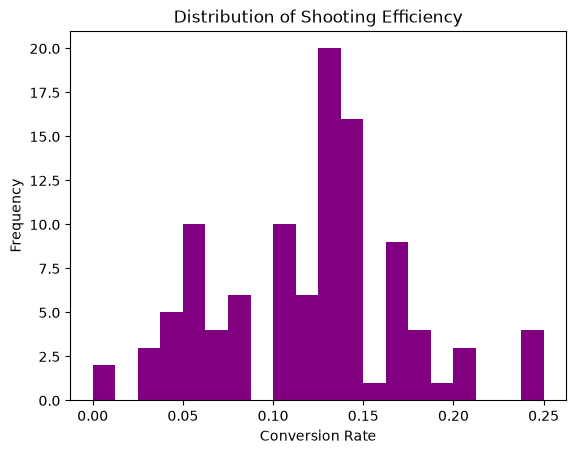

In [29]:
eff = home["Goals"] / home["Attempts_at_goal"]
plt.hist(eff, bins=20, color="purple")
plt.xlabel("Conversion Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Shooting Efficiency")


In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = home.corr(numeric_only=True)

corr.info()

<class 'pandas.DataFrame'>
Index: 24 entries, id to Possession_Control(%)
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  24 non-null     float64
 1   id.1                                24 non-null     float64
 2   venueId                             24 non-null     float64
 3   homeSquadId                         24 non-null     float64
 4   awaySquadId                         24 non-null     float64
 5   homeScore                           24 non-null     float64
 6   awayScore                           24 non-null     float64
 7   matchDay                            24 non-null     float64
 8   goal_diff                           24 non-null     float64
 9   rank                                24 non-null     float64
 10  team_id                             24 non-null     float64
 11  Goals                               24 non-

Text(0.5, 1.0, 'Correlation Heatmap - Home Teams')

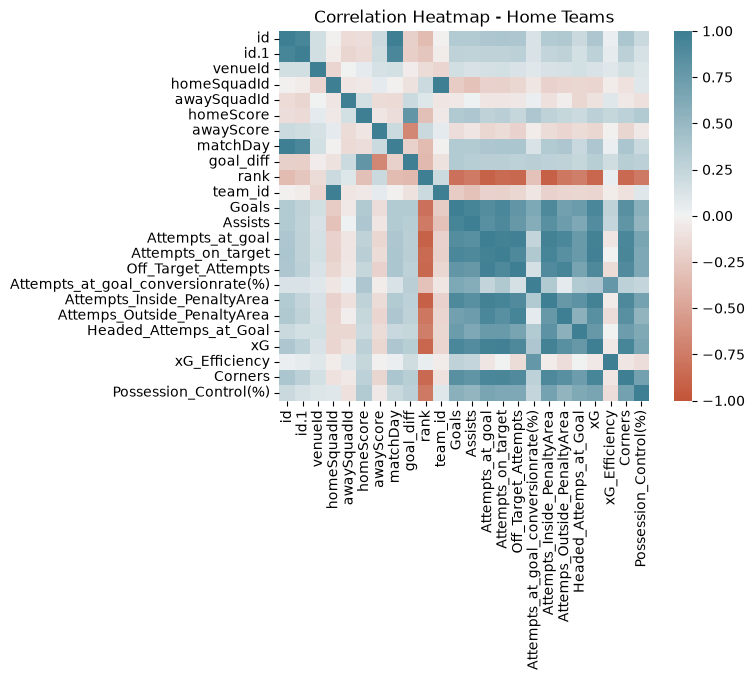

In [31]:
# create a heatmap visulisation of the home correlation data

sns.heatmap(corr,
            vmin=-1, vmax=1, center=0,
            cmap=sns.diverging_palette(20, 220, n=200),
            square=True
            )
plt.title("Correlation Heatmap - Home Teams")


<Axes: xlabel='Attempts_at_goal', ylabel='Goals'>

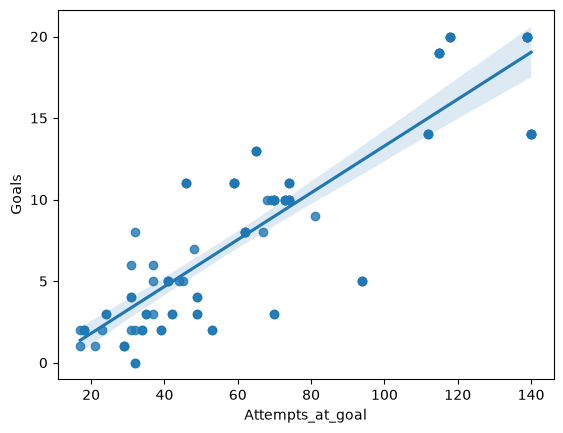

In [32]:
sns.regplot(x=home["Attempts_at_goal"], y=home["Goals"])


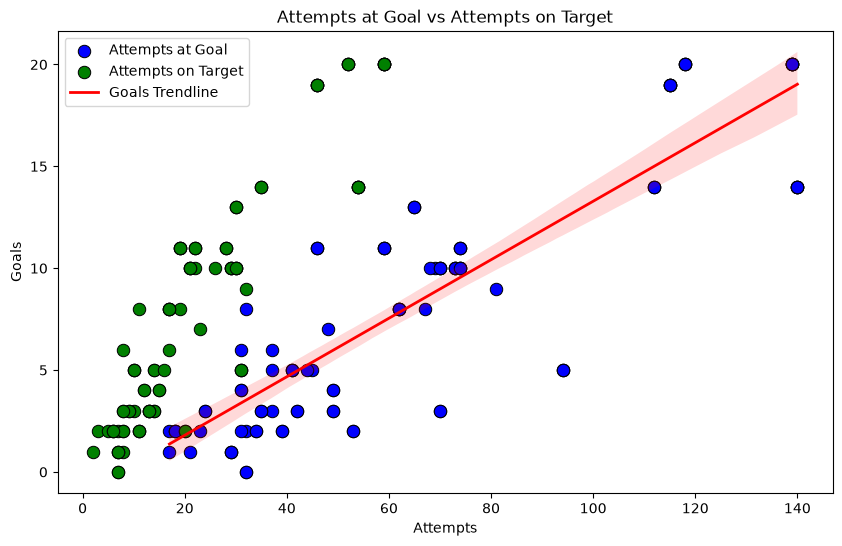

In [33]:
plt.figure(figsize=(10, 6))

# Blue = X relationship (Attempts_at_goal vs Goals)
sns.scatterplot(
    x=home["Attempts_at_goal"],
    y=home["Goals"],
    color="blue",
    s=80,
    edgecolor="black",
    label="Attempts at Goal"
)

# Green = Y relationship (Attempts_on_target vs Goals)
sns.scatterplot(
    x=home["Attempts_on_target"],
    y=home["Goals"],
    color="green",
    s=80,
    edgecolor="black",
    label="Attempts on Target"
)

# Regression line: Goals vs Attempts_at_goal (RED)
sns.regplot(
    x=home["Attempts_at_goal"],
    y=home["Goals"],
    scatter=False,
    line_kws={"color": "red", "linewidth": 2},
    label="Goals Trendline"
)

plt.xlabel("Attempts")
plt.ylabel("Goals")
plt.title("Attempts at Goal vs Attempts on Target")
plt.legend()
plt.show()


In [34]:
# Rename home columns with prefix
home_cols_map = {
    "Goals": "home_Goals",
    "Attempts_at_goal": "home_Attempts_at_goal",
    "Attempts_on_target": "home_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "home_ConversionRate",
    "Attempts_Inside_PenaltyArea": "home_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "home_Headed_attempts",
    "xG": "home_xG",
    "Possession_Control(%)": "home_Possession",
    "xG_Efficiency_num": "home_xG_eff"
}
home.rename(columns=home_cols_map, inplace=True)

In [35]:
# Away stats: merge again on awaySquadAbbr
full = home.merge(
    team_stats,
    left_on="awaySquadAbbr",
    right_on="TeamAbbr",
    how="left",
    suffixes=("", "_away")
)

In [36]:
away_cols_map = {
    "Goals": "away_Goals",
    "Attempts_at_goal": "away_Attempts_at_goal",
    "Attempts_on_target": "away_Attempts_on_target",
    "Attempts_at_goal_conversionrate(%)": "away_ConversionRate",
    "Attempts_Inside_PenaltyArea": "away_Attempts_inside_PA",
    "Headed_Attemps_at_Goal": "away_Headed_attempts",
    "xG": "away_xG",
    "Possession_Control(%)": "away_Possession",
    "xG_Efficiency_num": "away_xG_eff"
}
full.rename(columns=away_cols_map, inplace=True)

In [37]:
corr_away = full.corr(numeric_only=True)

Text(0.5, 1.0, 'Correlation Heatmap - Away Teams')

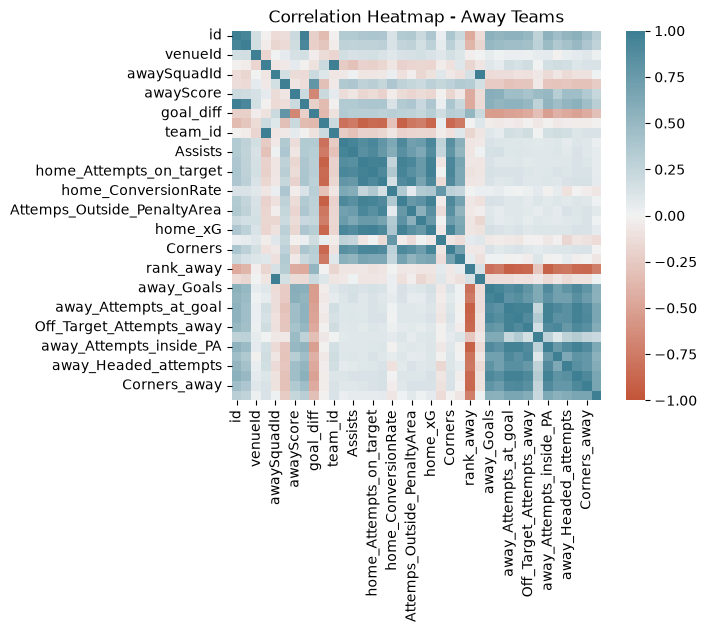

In [38]:
sns.heatmap(
    corr_away,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
plt.title("Correlation Heatmap - Away Teams")

In [39]:
# 6. Build eight explanatory variables as "home minus away"

full["diff_goals_scored"] = full["home_Goals"] - full["away_Goals"]
full["diff_attempts_at_goal"] = full["home_Attempts_at_goal"] - full["away_Attempts_at_goal"]
full["diff_attempts_on_target"] = full["home_Attempts_on_target"] - full["away_Attempts_on_target"]
full["diff_conversion_rate"] = full["home_ConversionRate"] - full["away_ConversionRate"]
full["diff_attempts_inside_pa"] = full["home_Attempts_inside_PA"] - full["away_Attempts_inside_PA"]
full["diff_headed_attempts"] = full["home_Headed_attempts"] - full["away_Headed_attempts"]
full["diff_xG"] = full["home_xG"] - full["away_xG"]
full["diff_possession"] = full["home_Possession"] - full["away_Possession"]

feature_cols = [
    "diff_goals_scored",
    "diff_attempts_at_goal",
    "diff_attempts_on_target",
    "diff_conversion_rate",
    "diff_attempts_inside_pa",
    "diff_headed_attempts",
    "diff_xG",
    "diff_possession"
]

In [40]:
full.head()

,id,voteStatus,stage,roundName,votingStartDate,votingEndDate,votingOpenedAt,selectedFormation,winners,formations,...,Corners_away,away_Possession,diff_goals_scored,diff_attempts_at_goal,diff_attempts_on_target,diff_conversion_rate,diff_attempts_inside_pa,diff_headed_attempts,diff_xG,diff_possession
0,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,11,46,8,31,10,9,31,8,5.62,2
1,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,37,0,-2,3,0,-1,-1,0.94,19
2,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,15,40,0,57,17,-9,39,8,5.28,13
3,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,10,27,8,24,11,10,30,8,4.38,25
4,1,complete,group,round_1,2026-06-18T05:00:00+01:00,2026-06-20T05:00:00+01:00,2026-06-18T09:10:01+01:00,NaN,"[1844, 1987, 2267, 2571]",NaN,...,28,49,-8,-57,-24,-2,-40,-5,-7.71,-18


In [41]:
# full.to_csv("full.csv", index=False)

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

In [43]:
# 7. Final dataset: 104 rows, 8 features + target

final_df = full[["goal_diff"] + feature_cols].dropna()

print("\nFinal dataset shape:", final_df.shape)
print("\nFeature list:")
for c in feature_cols:
    print("-", c)

print("\nPreview of dataset:")
print(final_df.head())


Final dataset shape: (104, 9)

Feature list:
- diff_goals_scored
- diff_attempts_at_goal
- diff_attempts_on_target
- diff_conversion_rate
- diff_attempts_inside_pa
- diff_headed_attempts
- diff_xG
- diff_possession

Preview of dataset:
   goal_diff  diff_goals_scored  diff_attempts_at_goal  \
0          2                  8                     31   
1          1                  0                     -2   
2          0                  0                     57   
3          3                  8                     24   
4          0                 -8                    -57   

   diff_attempts_on_target  diff_conversion_rate  diff_attempts_inside_pa  \
0                       10                     9                       31   
1                        3                     0                       -1   
2                       17                    -9                       39   
3                       11                    10                       30   
4                      -24   

In [44]:
# final_df.to_csv("FIFA-Objective3-Question2_1.csv", index=False)

In [45]:
# 8. Train-test split
X = final_df[feature_cols]
y = final_df["goal_diff"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [46]:
# 9. Linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.1 , 0.02,-0. ,..., 0.01, 0.13, 0.01]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['diff_goals_scored','diff_attempts_at_goal','diff_attempts_on_target',..., 'diff_headed_attempts','diff_xG','diff_possession']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.3373
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)


In [47]:
# 10. Evaluation
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nEvaluation metrics on test set:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R^2:", r2)


Evaluation metrics on test set:
MSE: 3.7731788872159067
RMSE: 1.9424672165099484
R^2: 0.24638954290660575


<strong>MSE ≈ 3.77</strong>
- The predictions are off by about 3.77 goals² on average.
- Not surprising — goal difference is a noisy target, and soccer matches often swing on randomness.

<strong>RMSE ≈ 1.94</strong>
- Interpretation: The model is typically off by about 2 goals.

<em>Goal difference is volatile, and you’re predicting it using aggregate tournament stats, not match‑specific context (lineups, injuries, tactics, red cards, weather, travel, rest days, etc.).</em>

<strong>R² ≈ 0.246</strong>
- The eight features explain about 24.6% of the variation in goal difference.

<em>In sports analytics, especially soccer, anything above 0.20 for raw goal difference prediction is decent unless you’re using deep match‑event data (xG per match, shot maps, player ratings, etc.).</em>

In [48]:
# 11. Coefficients interpretation
print("\nIntercept:", model.intercept_)
print("\nCoefficients:")
for name, coef in zip(feature_cols, model.coef_):
    print(f"{name}: {coef:.4f}")


Intercept: 0.3372512795870879

Coefficients:
diff_goals_scored: -0.1036
diff_attempts_at_goal: 0.0201
diff_attempts_on_target: -0.0006
diff_conversion_rate: 0.1535
diff_attempts_inside_pa: -0.0131
diff_headed_attempts: 0.0134
diff_xG: 0.1319
diff_possession: 0.0129


<h1>Interpreting Regression Output</h1>
<strong><em>Intercept: 0.337</em></strong>

If two teams were perfectly equal on all eight features, the model predicts: <strong>"Home team wins by ~0.34 goals"</strong>
- This is a tiny “home advantage” baked into the data — very normal in football analytics.

<h2>Feature by feature interpretation</h2>

“If this feature increases by 1 unit (home minus away), how much does goal difference change?”

<h3>diff_goals_scored: –0.1036</h3> This is surprising and interesting.

<h3>The negative sign suggests:</h3> Past goal totals are not a reliable predictor of match outcome. This often happens in tournaments where early mismatches inflate goal counts.

<h3>diff_attempts_at_goal: +0.0201</h3> More attempts → slightly more expected goal difference.

<h3>Every extra shot advantage adds ~0.02 goals.</h3>

<h3>diff_attempts_on_target: –0.0006</h3> = Basically zero.

<h3>Attempts on target don’t independently predict goal difference</h3> because they overlap heavily with xG and conversion rate.

<h3>diff_conversion_rate: +0.1535</h3> This is one of the strongest predictors in the model.

<p>
If the home team has a 1% higher conversion rate, goal difference increases by 0.15.  
A 10% advantage → +1.5 goals.
<p>

<h3>diff_attempts_inside_pa: –0.0131</h3>

<h2>The results suggest:</h2>

- Attempts inside the box alone don’t guarantee goals.

- diff_headed_attempts: +0.0134 - Teams with more headed chances tend to score slightly more.

- diff_xG: +0.1319 is the second strongest predictor.

- A 1‑goal xG advantage predicts +0.13 actual goal difference.

<h3>Modern analytics expects:</h3>

- xG is a strong, stable predictor of future scoring.

- diff_possession: +0.0129 | Tiny but positive.

- More possession → slightly more goals, but not much. Possession is a style metric, not a scoring metric.

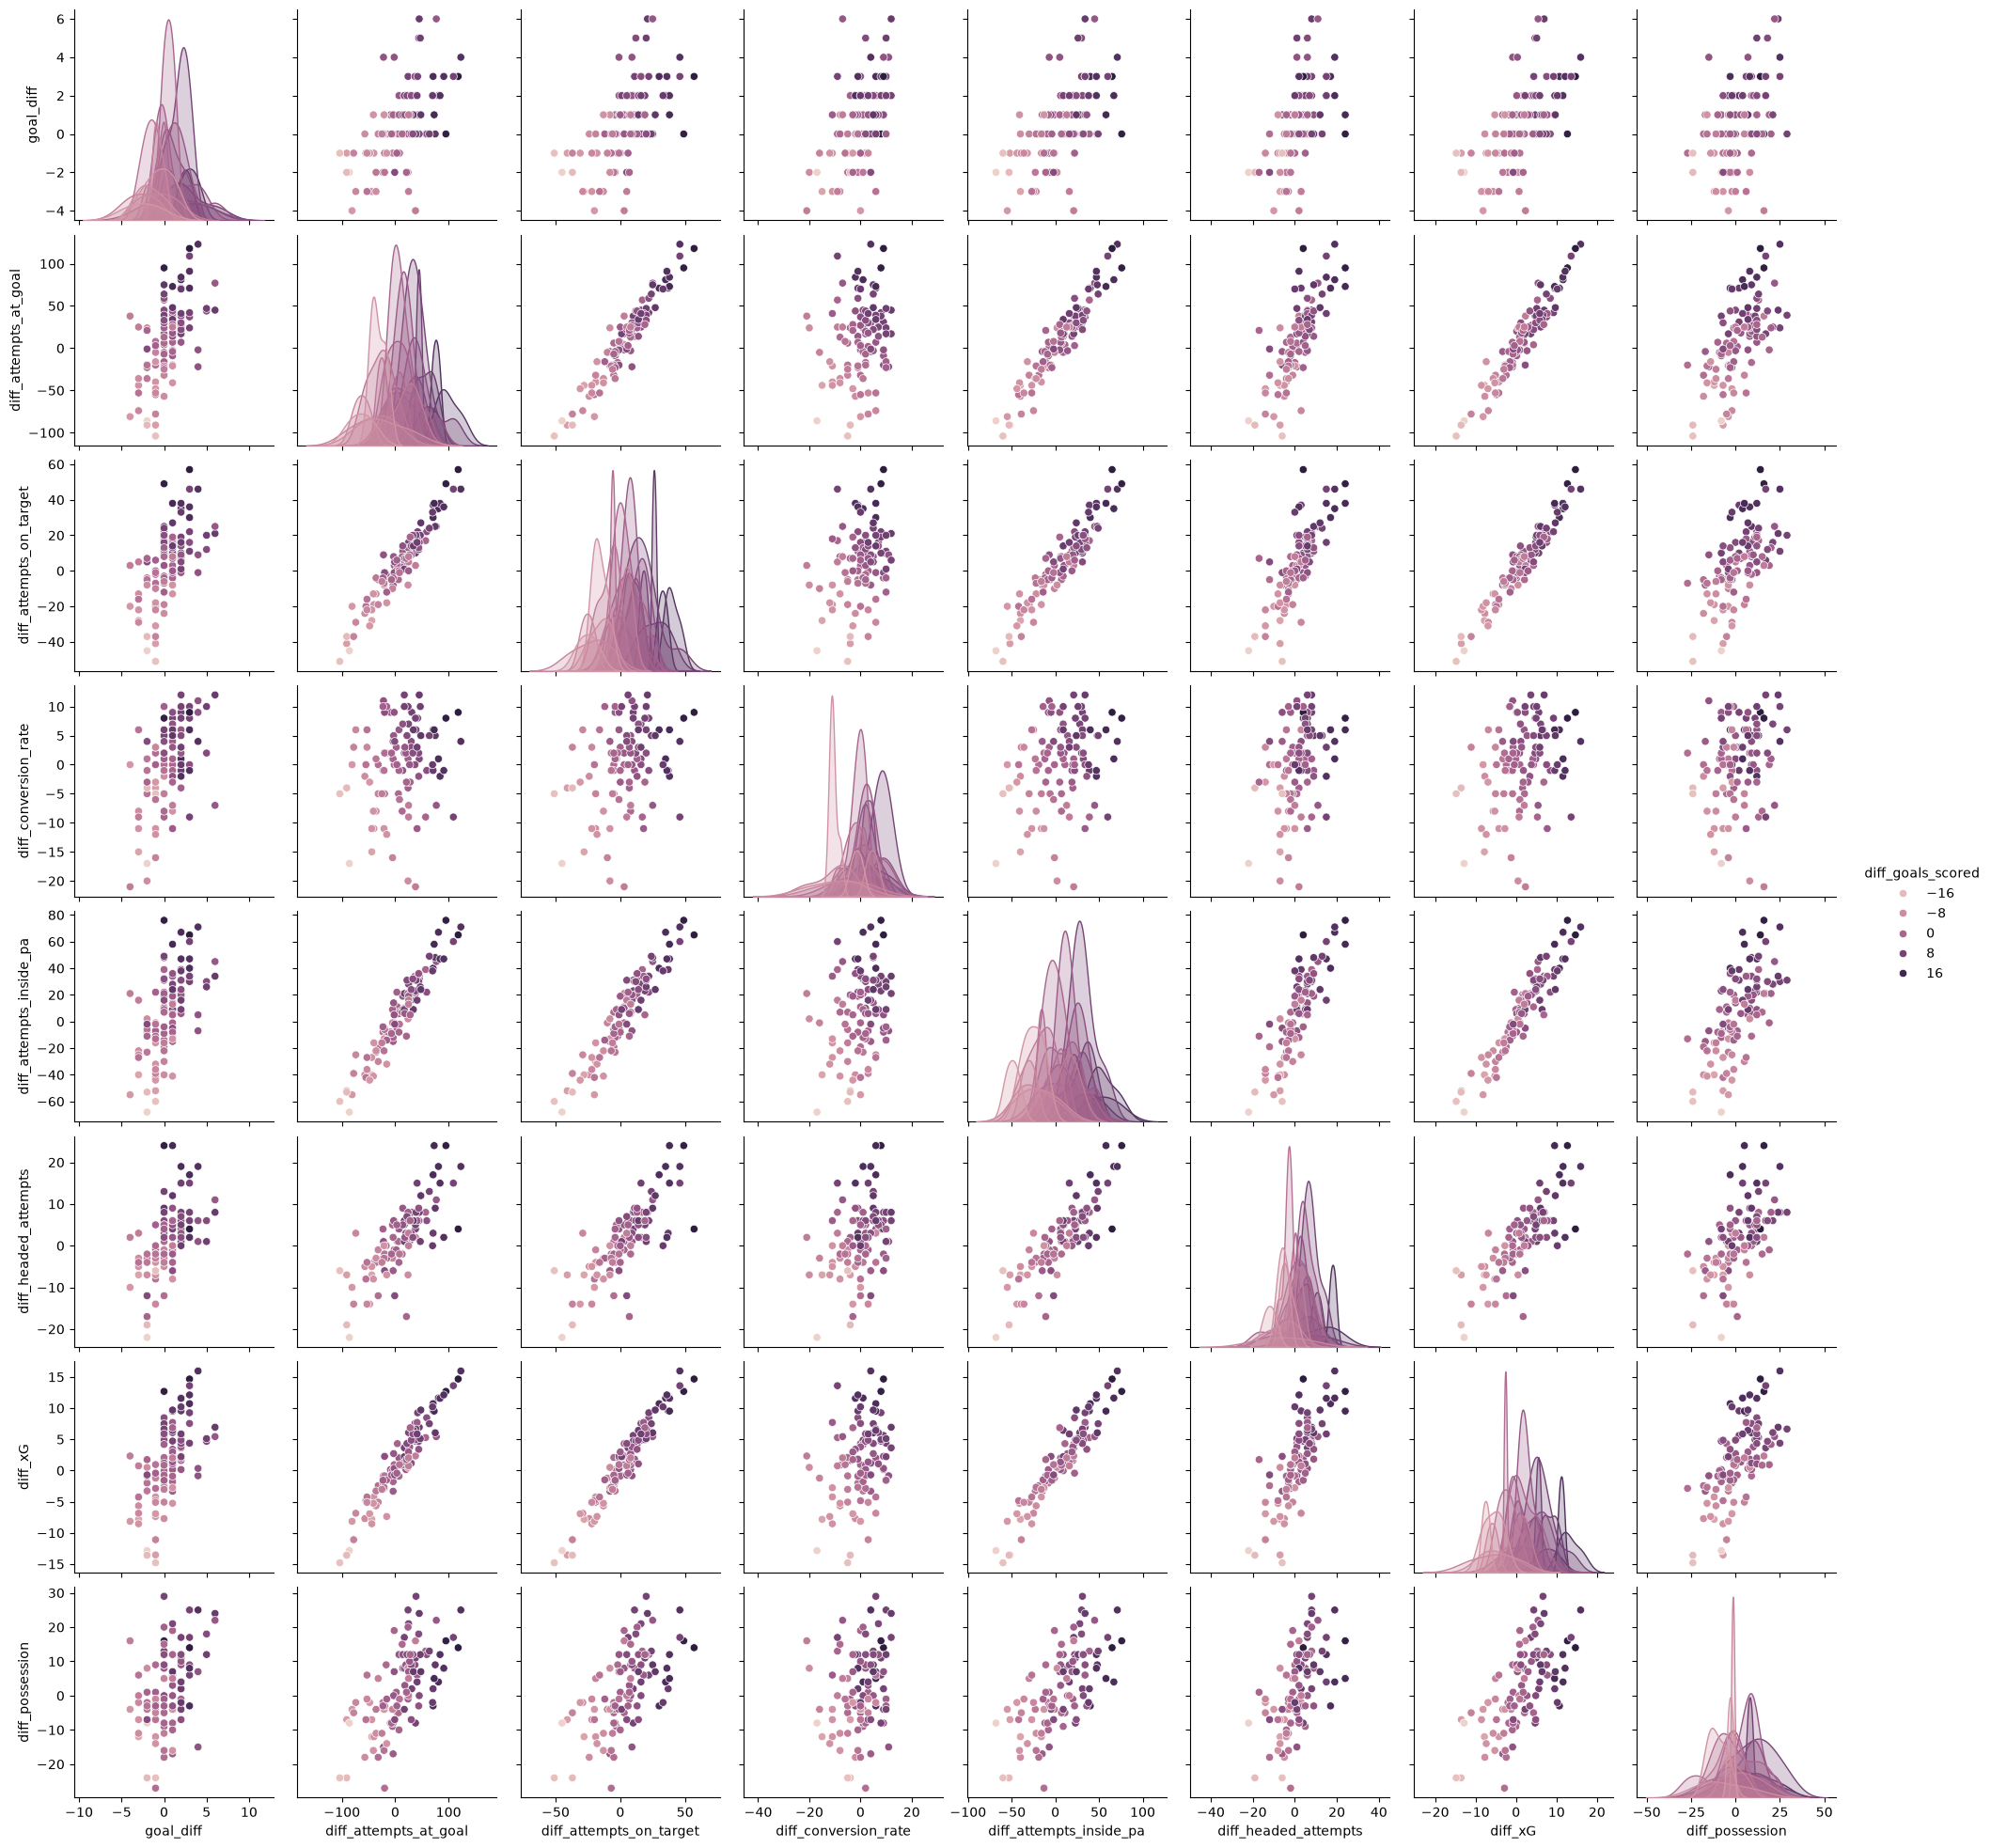

In [49]:
sns.pairplot(final_df, hue='diff_goals_scored')